In [ ]:
import numpy as np
import pandas as pd

In [ ]:
d=pd.read_csv('/content/drive/MyDrive/AI/titanic.csv')
d

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
d.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
d.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
from sklearn.impute import SimpleImputer
imputer_age = SimpleImputer(strategy='median')
imputer_age


SimpleImputer(strategy='median')

In [ ]:
imputer_embarked = SimpleImputer(strategy='most_frequent')

In [ ]:
d['Age'] = d['Age'].fillna(d['Age'].median())
d['Age']

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


In [ ]:
d['Embarked'] = d['Embarked'].fillna(d['Embarked'].mode()[0])
d['Embarked']

,Embarked
0,S
1,C
2,S
3,S
4,S
...,...
886,S
887,S
888,S
889,C


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

d['Sex'] = label_encoder.fit_transform(d['Sex'])
d['Embarked'] = label_encoder.fit_transform(d['Embarked'])

In [ ]:
X = d.drop('Survived', axis=1)
y = d['Survived']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
d.drop('Cabin', axis=1, inplace=True)
d.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

In [ ]:

from sklearn.ensemble import RandomForestClassifier

columns_to_drop = ['Name', 'Ticket', 'Cabin', 'PassengerId']

X_train_processed = X_train.drop(columns=columns_to_drop, errors='ignore').copy()
X_test_processed = X_test.drop(columns=columns_to_drop, errors='ignore').copy()

model = RandomForestClassifier(max_depth=3, random_state=42)
model.fit(X_train_processed, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

In [ ]:
y_pred = model.predict(X_test_processed)
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1])

In [ ]:
#Model Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE :",mse)
print("R2  :",r2)

MSE : 0.18994413407821228
R2  : 0.2167310167310167


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[94 11]
 [23 51]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       105
           1       0.82      0.69      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

    Feature  Importance
1       Sex    0.499901
0    Pclass    0.167032
5      Fare    0.160430
2       Age    0.071269
3     SibSp    0.049246
6  Embarked    0.026339
4     Parch    0.025782


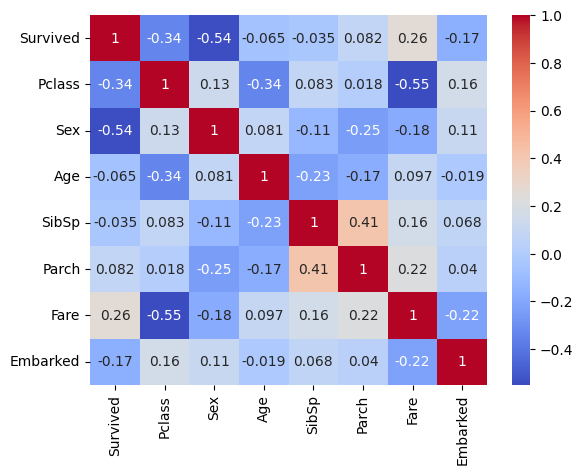

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = d.corr()
sns.heatmap(correlation_matrix,cmap='coolwarm',annot=True)
plt.show()

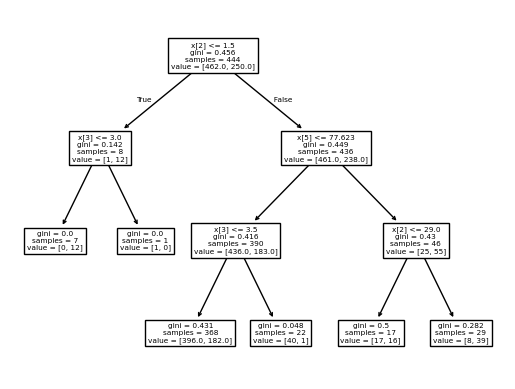

In [ ]:
#Data Visualization
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
fig=plt.figure()
plot_tree(model.estimators_[2])
plt.show()